# **Evolutionary Computing, lab 8 - Report**

**Authors**:
* **Kuba Czech**, 156035
* **Wojciech Nagórka**, 156045

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1. Description of the problem** ##

We are given a set of nodes, each defined by its x and y coordinates and an associated cost. The task is to select exactly half of the nodes (rounded up if the number is odd) and construct a Hamiltonian cycle that visits each selected node exactly once and returns to the starting node. The objective is to minimize the total sum of both the path length (computed using rounded Euclidean distances between nodes) and the costs of the selected nodes.

## **2. Similarity measures**

In [97]:
def node_similarity(sol1, sol2):
    set1 = set(sol1)
    set2 = set(sol2)
    intersection = len(set1.intersection(set2))
    return intersection

def edge_similarity(sol1, sol2):
    edges1 = set()
    edges2 = set()
    for i in range(len(sol1)-1):
        edge = (sol1[i], sol1[(i + 1) % len(sol1)])
        edges1.add(tuple(sorted(edge)))
    for i in range(len(sol2)-1):
        edge = (sol2[i], sol2[(i + 1) % len(sol2)])
        edges2.add(tuple(sorted(edge)))
    intersection = len(edges1.intersection(edges2))
    return intersection

def average_similarity(random_routes):
    routes = random_routes['route'].tolist()
    n = len(routes)

    avg_node = np.zeros(n)
    avg_edge = np.zeros(n)

    for i in range(n):
        node_vals = []
        edge_vals = []

        for j in range(n):
            if i == j:
                continue

            node_vals.append(node_similarity(routes[i], routes[j]))
            edge_vals.append(edge_similarity(routes[i], routes[j]))

        avg_node[i] = sum(node_vals) / (n - 1)
        avg_edge[i] = sum(edge_vals) / (n - 1)

    random_routes['sim_nodes_avg'] = avg_node
    random_routes['sim_edges_avg'] = avg_edge
    return random_routes

## **3. Plotting similarity vs cost**

In [116]:
def similarity_plot(data, title):
    sim_name = [i for i in data.columns if i != 'cost'][0]
    data = data[data[sim_name] != 100]

    plt.figure(figsize=(10, 6))
    plt.scatter(data['cost'], data[sim_name], marker='o')
    plt.title(title)
    plt.xlabel('Cost')
    plt.ylabel('Similarity')
    plt.grid(True)
    plt.show()

In [110]:
def read_best_solution(instance):
    best_solution = pd.read_csv(f'evaluation/{instance}_reference.csv', index_col='index').reset_index(drop=True)
    best_cost = best_solution['cost'][0]
    best_route = best_solution['route'][0]

    best_route = best_route.split('|')
    best_route[0] = best_route[0][1:]  # Remove leading '['
    best_route[-1] = best_route[-1][:-1]  # Remove trailing ']'
    best_route = [int(node) for node in best_route]

    return best_cost, best_route

def read_random_solutions(instance):
    random_solutions = pd.read_csv(f'evaluation/{instance}_local_optima.csv', index_col='index')
    random_solutions['route'] = random_solutions['route'].apply(lambda x: [int(node) for node in x[1:-1].split('|')])
    return random_solutions

### **3.1. Instance A**

#### **3.1.1. Reading data and pre-processing**

##### **3.1.1.1. Finding best solutions**

In [111]:
# Best solution for comparison:
tspa_overall_best_cost, tspa_overall_best_route = read_best_solution('TSPA')

In [112]:
# Read random solutions:
tspa_random_solutions = read_random_solutions('TSPA')

best_idx = tspa_random_solutions['cost'].idxmin()
tspa_random_best_cost, tspa_random_best_route = tspa_random_solutions.iloc[best_idx]['cost'], tspa_random_solutions.iloc[best_idx]['route']

##### **3.1.1.2. Similarity analysis**

In [129]:
tspa_random_solutions['sim_nodes_best_overall'] = tspa_random_solutions['route'].apply(lambda x: node_similarity(x, tspa_overall_best_route))
tspa_random_solutions['sim_edges_best_overall'] = tspa_random_solutions['route'].apply(lambda x: edge_similarity(x, tspa_overall_best_route))
tspa_random_solutions['sim_nodes_best_random'] = tspa_random_solutions['route'].apply(lambda x: node_similarity(x, tspa_random_best_route))
tspa_random_solutions['sim_edges_best_random'] = tspa_random_solutions['route'].apply(lambda x: edge_similarity(x, tspa_random_best_route))
tspa_random_solutions = average_similarity(tspa_random_solutions)
tspa_random_solutions

,cost,route,sim_nodes_best_overall,sim_edges_best_overall,sim_nodes_best_random,sim_edges_best_random,sim_nodes_avg,sim_edges_avg
index,,,,,,,,
0,74390.0,"[31, 157, 196, 81, 90, 27, 165, 119, 40, 185, ...",48,0,85,44,86.798799,44.346346
1,73824.0,"[148, 167, 52, 55, 57, 92, 129, 2, 1, 97, 152,...",50,0,87,46,88.906907,47.540541
2,76412.0,"[131, 149, 123, 127, 70, 135, 154, 180, 158, 5...",53,1,80,45,82.653654,42.430430
3,73634.0,"[193, 159, 22, 18, 108, 117, 143, 0, 46, 51, 1...",51,0,90,51,88.570571,44.917918
4,74627.0,"[9, 62, 144, 14, 138, 102, 49, 178, 106, 52, 1...",51,0,88,48,87.439439,42.438438
...,...,...,...,...,...,...,...,...
995,74344.0,"[89, 51, 151, 133, 79, 80, 176, 137, 23, 186, ...",49,0,86,46,87.896897,47.354354
996,73380.0,"[0, 143, 183, 89, 23, 186, 148, 137, 176, 80, ...",47,0,90,54,88.679680,48.725726
997,72708.0,"[143, 117, 0, 46, 68, 140, 108, 18, 22, 146, 1...",50,0,89,57,86.832833,48.484484


#### **3.1.2. Similarity with best solution overall**

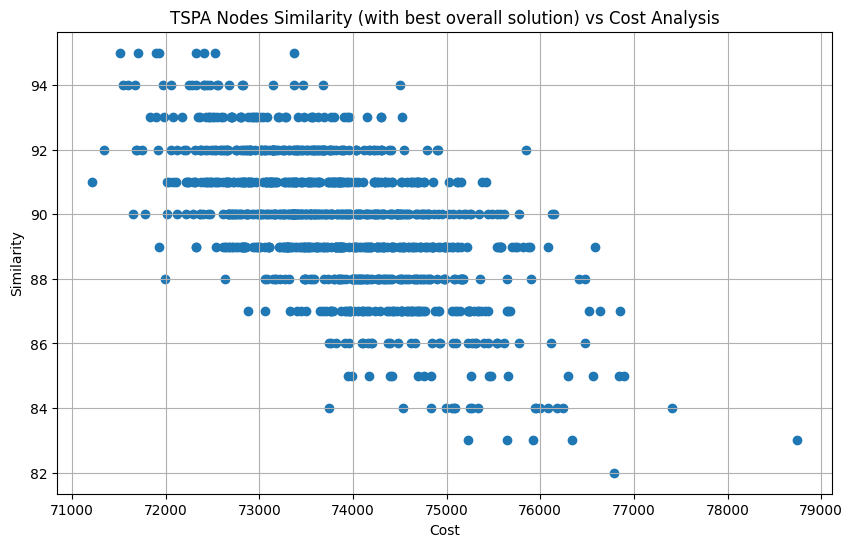

In [117]:
similarity_plot(tspa_random_solutions[['cost', 'sim_nodes_best_overall']], 'TSPA Nodes Similarity (with best overall solution) vs Cost Analysis')

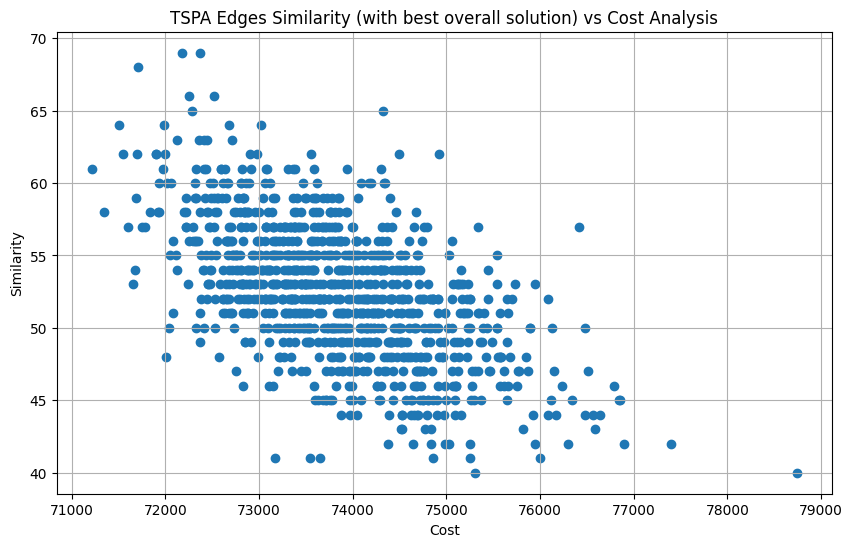

In [118]:
similarity_plot(tspa_random_solutions[['cost', 'sim_edges_best_overall']], 'TSPA Edges Similarity (with best overall solution) vs Cost Analysis')

#### **3.1.3. Similarity with best solution of all generated solutions**

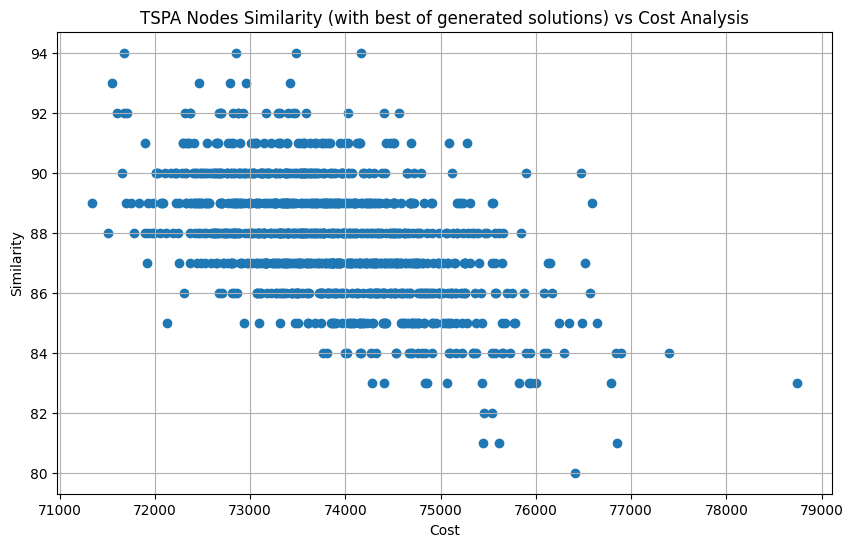

In [119]:
similarity_plot(tspa_random_solutions[['cost', 'sim_nodes_best_random']], 'TSPA Nodes Similarity (with best of generated solutions) vs Cost Analysis')

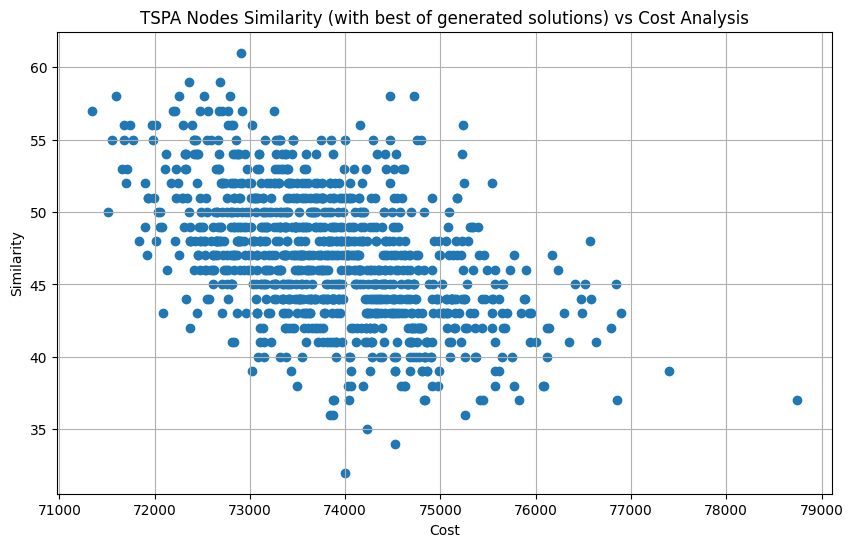

In [ ]:
similarity_plot(tspa_random_solutions[['cost', 'sim_edges_best_random']], 'TSPA Edges Similarity (with best of generated solutions) vs Cost Analysis')

#### **3.1.4. Average similarity with all other routes**

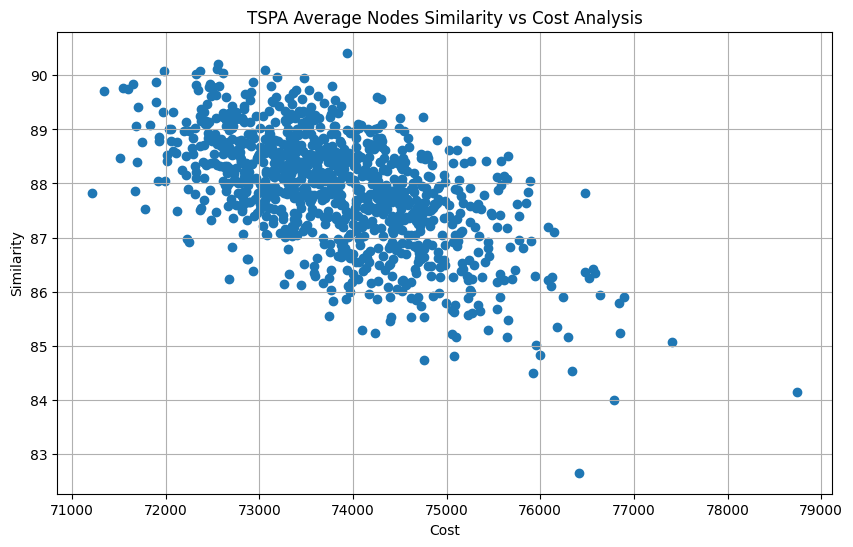

In [121]:
similarity_plot(tspa_random_solutions[['cost', 'sim_nodes_avg']], 'TSPA Average Nodes Similarity vs Cost Analysis')

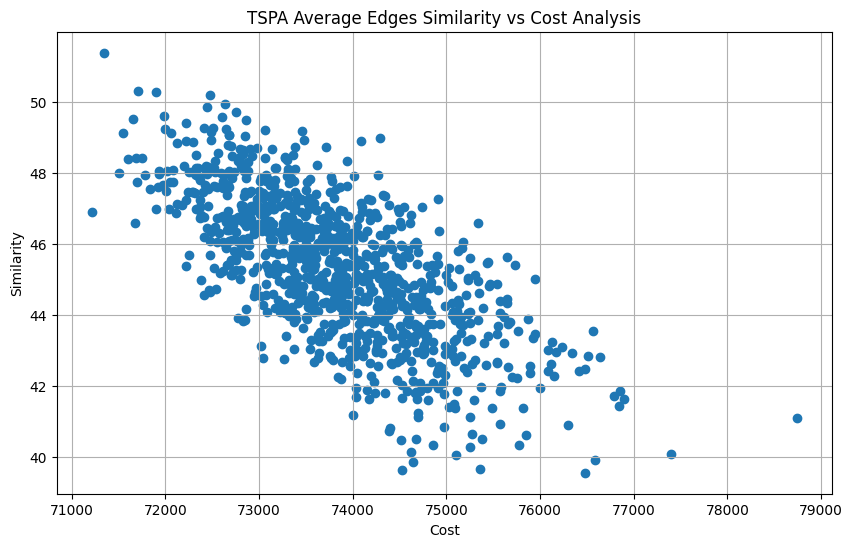

In [122]:
similarity_plot(tspa_random_solutions[['cost', 'sim_edges_avg']], 'TSPA Average Edges Similarity vs Cost Analysis')

### **3.2. Instance B**

#### **3.2.1. Reading data and pre-processing**

#### **3.2.1.1. Finding best solutions**

In [126]:
# Best solution for comparison:
tspb_overall_best_cost, tspb_overall_best_route = read_best_solution('TSPB')

In [127]:
# Read random solutions:
tspb_random_solutions = read_random_solutions('TSPB')

best_idx = tspb_random_solutions['cost'].idxmin()
tspb_random_best_cost, tspb_random_best_route = tspb_random_solutions.iloc[best_idx]['cost'], tspb_random_solutions.iloc[best_idx]['route']

##### **3.2.1.2. Similarity analysis**

In [128]:
tspb_random_solutions['sim_nodes_best_overall'] = tspb_random_solutions['route'].apply(lambda x: node_similarity(x, tspb_overall_best_route))
tspb_random_solutions['sim_edges_best_overall'] = tspb_random_solutions['route'].apply(lambda x: edge_similarity(x, tspb_overall_best_route))
tspb_random_solutions['sim_nodes_best_random'] = tspb_random_solutions['route'].apply(lambda x: node_similarity(x, tspb_random_best_route))
tspb_random_solutions['sim_edges_best_random'] = tspb_random_solutions['route'].apply(lambda x: edge_similarity(x, tspb_random_best_route))
tspb_random_solutions = average_similarity(tspb_random_solutions)
tspb_random_solutions

,cost,route,sim_nodes_best_overall,sim_edges_best_overall,sim_nodes_best_random,sim_edges_best_random,sim_nodes_avg,sim_edges_avg
index,,,,,,,,
0,49282.0,"[31, 54, 117, 1, 135, 63, 122, 133, 90, 191, 1...",84,45,85,41,83.024024,41.796797
1,47331.0,"[15, 145, 189, 109, 35, 0, 29, 49, 160, 33, 13...",89,56,88,50,83.834835,43.857858
2,48251.0,"[148, 20, 28, 140, 183, 152, 34, 55, 18, 62, 1...",85,54,84,45,84.763764,43.836837
3,47930.0,"[3, 155, 152, 140, 183, 148, 47, 94, 179, 185,...",85,53,83,52,83.517518,45.307307
4,50840.0,"[36, 141, 77, 81, 153, 163, 113, 176, 194, 166...",82,49,81,42,80.860861,36.617618
...,...,...,...,...,...,...,...,...
995,49817.0,"[131, 90, 191, 51, 98, 134, 74, 118, 25, 182, ...",82,45,83,48,81.484484,42.442442
996,48809.0,"[174, 55, 18, 62, 124, 34, 152, 155, 3, 70, 15...",84,47,82,40,82.908909,41.437437
997,49314.0,"[51, 125, 90, 191, 10, 133, 122, 135, 63, 38, ...",81,42,81,45,80.666667,39.544545


#### **3.2.2. Similarity with best solution overall**

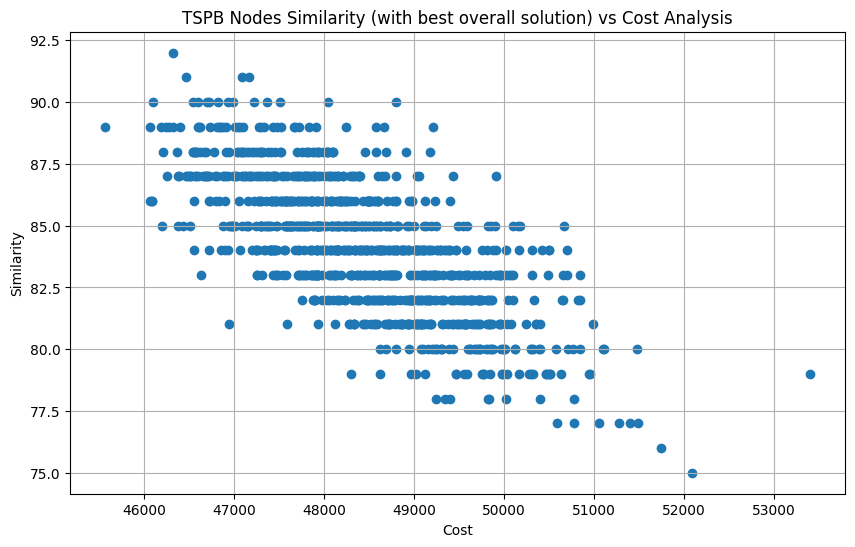

In [131]:
similarity_plot(tspb_random_solutions[['cost', 'sim_nodes_best_overall']], 'TSPB Nodes Similarity (with best overall solution) vs Cost Analysis')

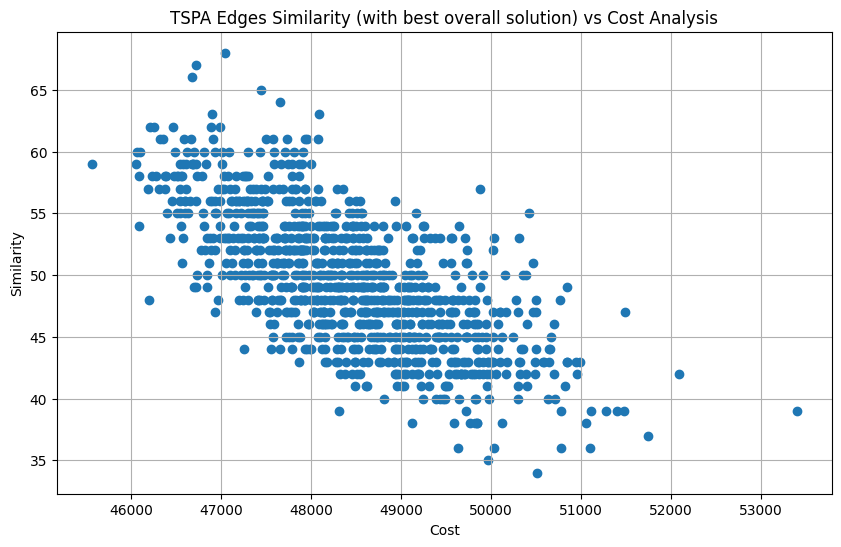

In [135]:
similarity_plot(tspb_random_solutions[['cost', 'sim_edges_best_overall']], 'TSPA Edges Similarity (with best overall solution) vs Cost Analysis')

#### **3.2.3. Similarity with best solution of all generated solutions**

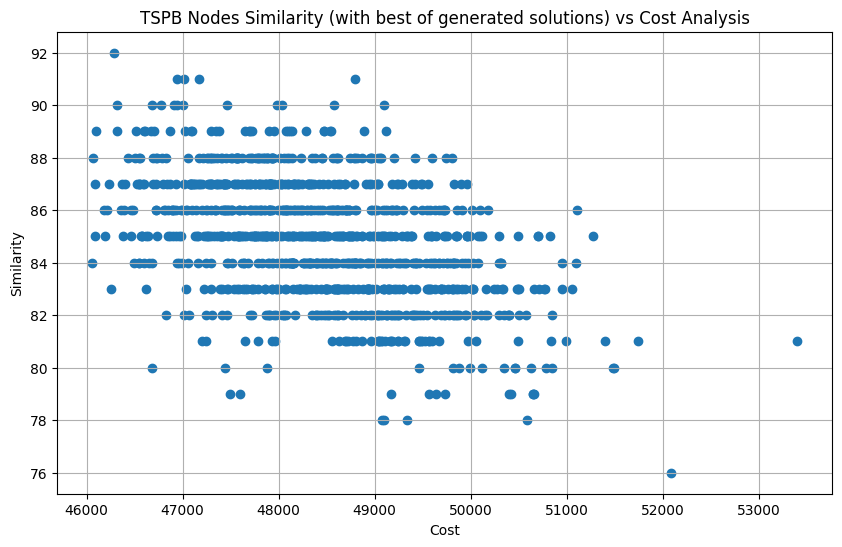

In [137]:
similarity_plot(tspb_random_solutions[['cost', 'sim_nodes_best_random']], 'TSPB Nodes Similarity (with best of generated solutions) vs Cost Analysis')

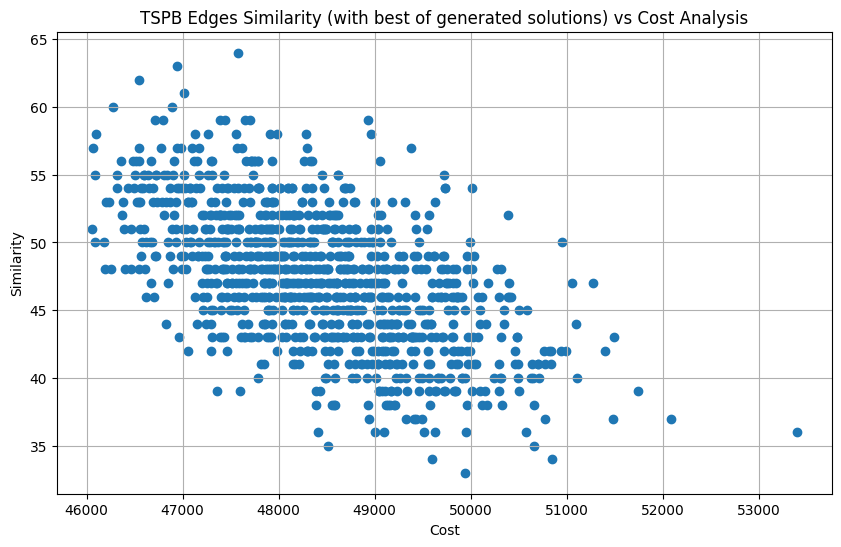

In [138]:
similarity_plot(tspb_random_solutions[['cost', 'sim_edges_best_random']], 'TSPB Edges Similarity (with best of generated solutions) vs Cost Analysis')

#### **3.2.4. Average similarity with all other routes**

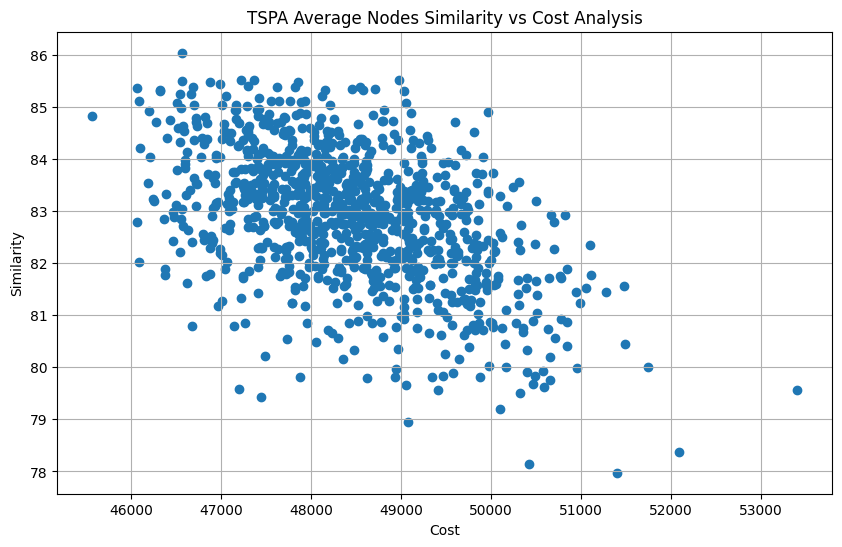

In [139]:
similarity_plot(tspb_random_solutions[['cost', 'sim_nodes_avg']], 'TSPA Average Nodes Similarity vs Cost Analysis')

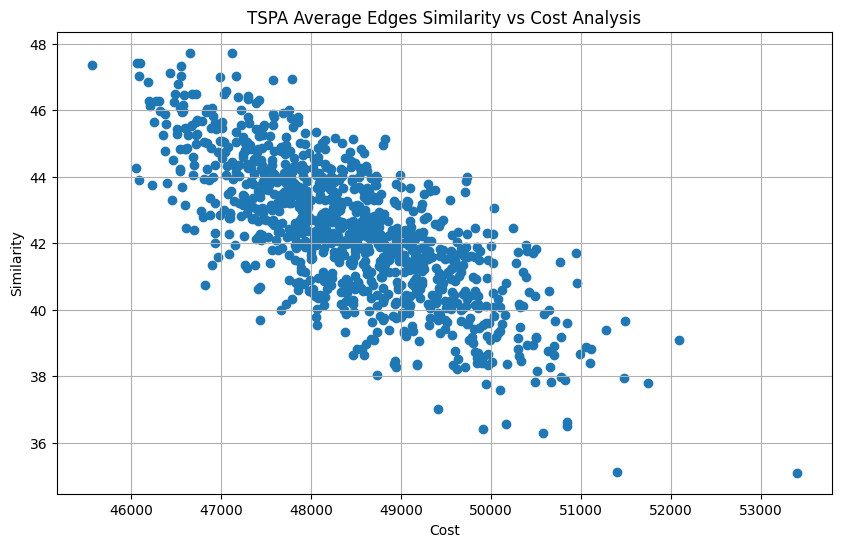

In [140]:
similarity_plot(tspb_random_solutions[['cost', 'sim_edges_avg']], 'TSPA Average Edges Similarity vs Cost Analysis')

## **4. Usage of solution checker**

Solution checker was used for all computed above solutions and value of objective functions are correct.

## **5. Link to the source code** ##

https://github.com/WojtekNagorka/Evolutionary-computation/tree/main/lab8

## **6. Conclusions**

**TODO**